Librerías Usadas

In [1]:
!pip install pulp

In [2]:
import pulp

In [3]:
import numpy as np
from scipy import linalg
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Punto 1: Mezcla de fertilizantes
Una empresa agrícola fabrica dos tipos de fertilizante mezclando
tres compuestos químicos (A, B, C). Tiene disponibles 120 kg de A,
80 kg de B y 150 kg de C por semana. Cada tonelada producida
genera una ganancia de \$180 (Fertilizante F1) y \$220 (Fertilizante
F2).

## Función objetivo:
$𝑍=180X_1+220X_2$

In [4]:
modelo = pulp.LpProblem("Fertilizantes", pulp.LpMaximize)

# Variables de decisión (no negativas)
x1 = pulp.LpVariable('F1', lowBound=0, cat='Continuous')
x2 = pulp.LpVariable('F2', lowBound=0, cat='Continuous')

# Función objetivo
modelo += 180 * x1 + 220 * x2, "Ganancia_Total"

# Restricciones
modelo += 3 * x1 + 4 * x2 <= 120, "Compuesto_A"
modelo += 2 * x1 + 1 * x2 <= 80, "Compuesto_B"
modelo += 5 * x1 + 3 * x2 <= 150, "Compuesto_C"

In [5]:
# Resolver
modelo.solve()

# Resultados
print("=== Mezcla de fertilizantes ===")
print("Estado:", pulp.LpStatus[modelo.status])
print("Producción óptima de F1:", x1.varValue, "toneladas")
print("Producción óptima de F2:", x2.varValue, "toneladas")
print("Ganancia máxima: $", pulp.value(modelo.objective))

=== Mezcla de fertilizantes ===
Estado: Optimal
Producción óptima de F1: 21.818182 toneladas
Producción óptima de F2: 13.636364 toneladas
Ganancia máxima: $ 6927.27284


# Punto 2: Producción semanal de una fábrica
Una fábrica produce sillas y mesas. La producción de la semana
siguiente depende de la demanda de la semana actual según las
siguientes relaciones:

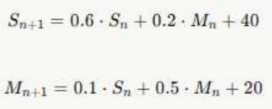

Donde $S_n$ es el número de sillas producidas en la semana $n$ y $M_n$
el número de mesas. Se parte de $S_0 = 200$ sillas y $M_0 = 80$ mesas.

In [6]:
# Condiciones iniciales
S0, M0 = 200, 80

# Matriz de coeficientes y vector constante
A = np.array([[0.6, 0.2],
              [0.1, 0.5]])
b = np.array([40, 20])

In [7]:
# Simulación de las primeras semanas
S, M = S0, M0
print("=== Producción semanal de la fábrica ===")
print(f"Semana 0: S = {S}, M = {M}")

for n in range(1, 6):  # simulamos 5 semanas
    S_next, M_next = A @ np.array([S, M]) + b
    S, M = S_next, M_next
    print(f"Semana {n}: S = {S:.2f}, M = {M:.2f}")

# --- Punto de equilibrio ---
# En equilibrio: (S, M) = A @ (S, M) + b
# => (I - A)(S, M) = b
I = np.eye(2)
equilibrio = linalg.solve(I - A, b)

print("\nPunto de equilibrio:")
print(f"Sillas = {equilibrio[0]:.2f}, Mesas = {equilibrio[1]:.2f}")

=== Producción semanal de la fábrica ===
Semana 0: S = 200, M = 80
Semana 1: S = 176.00, M = 80.00
Semana 2: S = 161.60, M = 77.60
Semana 3: S = 152.48, M = 74.96
Semana 4: S = 146.48, M = 72.73
Semana 5: S = 142.43, M = 71.01

Punto de equilibrio:
Sillas = 133.33, Mesas = 66.67


# Punto 3: Epidemia en una ciudad
En una ciudad de 10,000 habitantes se modela la propagación de una
enfermedad. El modelo SIS divide la población en: $S(t) =$
susceptibles e $I(t) =$ infectados. La tasa de nuevos contagios es
proporcional al producto $S · I$ (contacto entre grupos) y los
infectados se recuperan a tasa γ = 0.1 por día. La tasa de
contagio es $β = 0.00003$ por día.
Como la población total es constante: $S(t) + I(t) = 10,000$, el
modelo se reduce a:

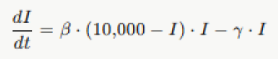

Se inicia con $I(0) = 50$ personas infectadas.

In [8]:
# Condición inicial
I0 = 50

# Parámetros
beta = 0.00003
gamma = 0.1
N = 10000

# Ecuación diferencial
def dI_dt(t, I):
    return beta * (N - I) * I - gamma * I

=== Epidemia en una ciudad ===
Día 0: I(t) ≈ 50.00 infectados
Día 30: I(t) ≈ 5037.22 infectados
Día 60: I(t) ≈ 6660.66 infectados
Día 90: I(t) ≈ 6666.52 infectados
Día 120: I(t) ≈ 6666.11 infectados
Día 150: I(t) ≈ 6667.74 infectados

Equilibrio endémico esperado:
I* ≈ 6666.67 infectados


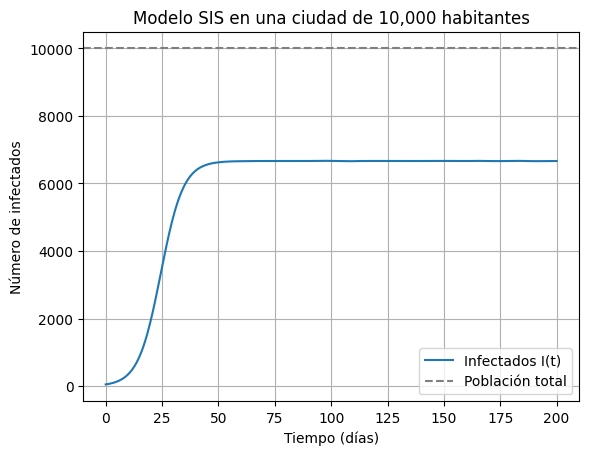

In [9]:
# Intervalo de tiempo (ejemplo: 0 a 200 días)
t_span = (0, 200)
t_eval = np.linspace(t_span[0], t_span[1], 500)

# Resolver con solve_ivp
sol = solve_ivp(dI_dt, t_span, [I0], t_eval=t_eval)

# Imprimir valores en consola
dias_interes = [0, 30, 60, 90, 120, 150]

print("=== Epidemia en una ciudad ===")
for d in dias_interes:
    # Buscar el valor más cercano en la solución
    idx = np.argmin(np.abs(sol.t - d))
    print(f"Día {d}: I(t) ≈ {sol.y[0][idx]:.2f} infectados")

# Equilibrio analítico
I_equilibrio = N - gamma/beta
print("\nEquilibrio endémico esperado:")
print(f"I* ≈ {I_equilibrio:.2f} infectados")

# Graficar
plt.plot(sol.t, sol.y[0], label="Infectados I(t)")
plt.axhline(y=N, color="gray", linestyle="--", label="Población total")
plt.xlabel("Tiempo (días)")
plt.ylabel("Número de infectados")
plt.title("Modelo SIS en una ciudad de 10,000 habitantes")
plt.legend()
plt.grid(True)
plt.show()

# Punto 4: Modelo logístico de pesca
Una laguna tiene una población de peces que crece logísticamente.
Cada año se extraen $H = 80$ peces por pesca controlada. La
capacidad máxima de la laguna es $K = 1000$ peces y la tasa de
crecimiento intrínseca es $r = 0.4$.

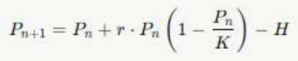

Se parte de una población inicial de $P_0 = 400$ peces.

In [10]:
# Parámetros
r = 0.4
K = 1000
H = 80
P0 = 400

# Número de años a simular
n_years = 20

# Inicialización
P = P0

In [11]:
print("=== Modelo logístico de pesca ===")
print(f"Año 0: P = {P}")

for n in range(1, n_years + 1):
    P = P + r * P * (1 - P/K) - H
    print(f"Año {n}: P = {P:.2f}")

# --- Equilibrio ---
# En equilibrio: P = P + r*P*(1 - P/K) - H
# => r*P*(1 - P/K) = H
# => r*P - (r/K)*P^2 = H
# => (r/K)*P^2 - r*P + H = 0
a = r/K
b = -r
c = H

equilibrios = np.roots([a, b, c])
print("\nPosibles equilibrios:")
for eq in equilibrios:
    if eq > 0:
        print(f"P* ≈ {eq:.2f} peces")

=== Modelo logístico de pesca ===
Año 0: P = 400
Año 1: P = 416.00
Año 2: P = 433.18
Año 3: P = 451.39
Año 4: P = 470.45
Año 5: P = 490.10
Año 6: P = 510.06
Año 7: P = 530.02
Año 8: P = 549.66
Año 9: P = 568.67
Año 10: P = 586.78
Año 11: P = 603.77
Año 12: P = 619.46
Año 13: P = 633.76
Año 14: P = 646.60
Año 15: P = 658.00
Año 16: P = 668.02
Año 17: P = 676.73
Año 18: P = 684.23
Año 19: P = 690.66
Año 20: P = 696.12

Posibles equilibrios:
P* ≈ 723.61 peces
P* ≈ 276.39 peces
